Platform Expansion and Labour-Market Vulnerability in India: Evidence from the COVID-19 Shock and Employment Protection Gaps

1. Introduction

India’s gig and platform economy has expanded rapidly in transport, delivery, and online services, often under task-based arrangements that blur self-employment and wage work and weaken employer liability. NITI Aayog (2022) estimates about 7.7 million gig workers in 2020–21 and projects over 23 million by 2029–30, highlighting rising macroeconomic relevance. Evidence, however, links platform work to weaker job quality, limited security, and gaps in formal protections (Rani & Dhir, 2020; Sharma & Sharma, 2025).

COVID-19 provides a sharp test of this trade-off. Informal workers faced disproportionate employment and income losses during lockdowns, consistent with risk amplification under missing contracts and social insurance (Bussolo et al., 2021). Platform workers, even in “essential” services, experienced earnings volatility and uneven protective coverage; qualitative accounts emphasize contractor status, piece-rate pay, and algorithmic control that shifted risk onto workers (Rani & Dhir, 2020; Parwez, 2022). Across studies, weak employment protection—absence of written contracts and exclusion from social security—emerges as the core channel (Z), yet there is limited descriptive evidence on how exposure and protection gaps vary across states and rural–urban labour markets.

This project addresses that gap by combining PLFS microdata with CMIE Unemployment in India indicators. The research question is: Did the COVID-19 shock increase states’ exposure to platform-adjacent employment in India (X), raising labour-market vulnerability (Y) through weaker employment protection (Z), proxied by the absence of written contracts and social security coverage? Summary tables and figures show a broad post-COVID rise in gig exposure, while vulnerable employment remains persistently high and increases across demographic groups. State-level patterns suggest a positive X–Y association with substantial heterogeneity in Z, implying precarity does not scale one-for-one with gig intensity.


2. Data Cleaning / Loading

The assigned dataset is CMIE Unemployment in India (2019–2020), reporting monthly unemployment rates and labour force participation rates (LFPR) at the state × rural/urban level. CMIE captures high-frequency conditions around COVID-19 but lacks worker- and job-level characteristics and has limited temporal coverage for examining employment structure and protection mechanisms.

2.1 Other Datasets

To measure the mechanism (Z) and extend coverage, I merged CMIE with Periodic Labour Force Survey (PLFS) microdata (2018–2024) from the Government of India. PLFS is nationally representative and includes employment status, occupation, enterprise type, workplace attachment, contract status, social security coverage, and demographics. To harmonize temporal and geographical coverage, PLFS records are aggregated using survey weights to state × year × quarter × rural/urban, while CMIE monthly indicators are averaged to quarters. The datasets are merged using state identifier, year, quarter, and rural/urban classification, yielding a unified quarterly panel that supports pre-, during-, and post-COVID comparisons and adds gig-specific and protection variables unavailable in CMIE.

2.2 Key Variables

The outcome (Y) is vulnerable employment share: the proportion of employed workers who are own-account workers or unpaid family workers (ILO concept), capturing weak security and limited institutional protection.
The mechanism (Z) is a Gig Precarity Index, defined as the arithmetic mean of three protection-deficit shares among gig workers: no written job contract, no paid leave or benefits, and no social security coverage.
The main explanatory variable (X) is gig employment share (principal status): the proportion of employed workers whose primary activity is classified as gig or platform-adjacent work, interpreted as labour-market exposure to platform-mediated employment.

Additional X variables capture channels emphasized in the platform-work literature and in NITI Aayog (2022): (i) the gig volatility wedge (absolute gap between current weekly status and principal-status gig shares) to proxy short-horizon intermittency; (ii) small or informal enterprise share and no fixed workplace share to proxy informality and weak firm attachment where protections are harder to enforce; and (iii) demographic composition—share aged 15–34, share with secondary or tertiary education, and the male-to-female ratio within gig employment—to capture sorting across groups with different bargaining power and outside options. Together, these variables assess whether higher X aligns with higher Y through protection deficits Z, particularly around COVID.

In [9]:
# ======================
# Load datasets
# ======================
import pandas as pd
import numpy as np

plfs = pd.read_csv("plfs_2018_2024.csv")
unemp = pd.read_csv("unemp_quarterly_agg.csv")

# ======================
# 1) Standardize PLFS keys
# ======================
for c in ["year_label", "quarter", "state"]:
    plfs[c] = plfs[c].astype(str).str.strip()

# Ensure PLFS has a "region" column (Rural/Urban)
if "region" not in plfs.columns:
    if "sector_ru" in plfs.columns:
        plfs["region"] = plfs["sector_ru"]
    elif "sector" in plfs.columns:
        plfs["region"] = plfs["sector"].map({1: "Rural", 2: "Urban", "1": "Rural", "2": "Urban"})
    else:
        raise KeyError("PLFS must have either 'region', 'sector_ru', or 'sector'.")

plfs["region"] = plfs["region"].astype(str).str.strip().str.title()

# Standardize quarter format
plfs["quarter"] = (
    plfs["quarter"].astype(str).str.strip().str.upper()
        .replace({"1": "Q1", "2": "Q2", "3": "Q3", "4": "Q4"})
)

# ======================
# 2) Standardize UNEMP keys (and rename sector_ru -> region)
# ======================
for c in ["year_label", "quarter", "state", "sector_ru"]:
    if c not in unemp.columns:
        raise KeyError(f"Unemp is missing '{c}'. Found: {list(unemp.columns)}")
    unemp[c] = unemp[c].astype(str).str.strip()

unemp["region"] = unemp["sector_ru"].astype(str).str.strip().str.title()
unemp["quarter"] = (
    unemp["quarter"].astype(str).str.strip().str.upper()
        .replace({"1": "Q1", "2": "Q2", "3": "Q3", "4": "Q4"})
)

# (Optional) drop sector_ru now that region exists
unemp = unemp.drop(columns=["sector_ru"], errors="ignore")

# ======================
# 3) Merge: KEEP ALL PLFS OBS (LEFT JOIN)
# ======================
keys = ["year_label", "quarter", "state", "region"]

plfs["_in_plfs"] = 1
unemp["_in_unemp"] = 1

merged = plfs.merge(unemp, on=keys, how="left")

merged["_in_plfs"] = merged["_in_plfs"].fillna(0).astype(int)
merged["_in_unemp"] = merged["_in_unemp"].fillna(0).astype(int)

# ======================
# 4) Sort earliest -> latest (fiscal-year start)
# ======================
merged["fy_start"] = pd.to_numeric(merged["year_label"].str[:4], errors="coerce")
qmap = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
merged["q_num"] = merged["quarter"].map(qmap)

region_order = {"Rural": 0, "Urban": 1}
merged["region_order"] = merged["region"].map(region_order).fillna(2)

merged = (
    merged.sort_values(["fy_start", "q_num", "state", "region_order"])
          .drop(columns=["fy_start", "q_num", "region_order", "_in_plfs", "unemployment_rate_pct", "lfpr_pct", "_in_unemp"])
          .reset_index(drop=True)
)

# ======================
# 5) Save
# ======================
out_path = "final_dataset.csv"
merged.to_csv(out_path, index=False)
print("Saved:", out_path)
print("PLFS rows:", len(plfs), "| Merged rows (should match PLFS):", len(merged))


Saved: final_dataset.csv
PLFS rows: 1691 | Merged rows (should match PLFS): 1691


3. Summary Statistics Tables

In [18]:
# Summary Tables
import numpy as np
from IPython.display import HTML, display

# ======================
# 1. Load and Process Data 
# ======================
df = pd.read_csv("final_dataset.csv") 

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Define Variables
Y = "vulnerable_employment_share"
X_gig_share = "gig_occupation_code_share"
X_wedge = "gig_volatility_wedge_occ"
X_informal_enterprise = "gig_num_workers_enterprise_share"
X_no_fixed_workplace = "gig_workplace_location_code_share"

# Create new X variables
df["X_gig_age_15_34_share_within_gig"] = to_num(df["gig_age_15_24_share_within_gig"]) + to_num(df["gig_age_25_34_share_within_gig"])
df["X_gig_edu_secondary_tertiary_share_within_gig"] = to_num(df["gig_edu_secondary_share_within_gig"]) + to_num(df["gig_edu_tertiary_share_within_gig"])
df["X_gig_male_female_ratio"] = to_num(df["gig_male_share_within_gig"]) / to_num(df["gig_female_share_within_gig"]).replace(0, np.nan)

vars_main = [Y, X_gig_share, X_wedge, X_informal_enterprise, X_no_fixed_workplace, 
             "X_gig_age_15_34_share_within_gig", "X_gig_edu_secondary_tertiary_share_within_gig", "X_gig_male_female_ratio"]

clean_labels = {
    Y: "Vulnerable employment share (%)",
    X_gig_share: "Gig exposure share (principal, %)",
    X_wedge: "Gig volatility wedge (|CWS − principal|, pp)",
    X_informal_enterprise: "Small/Informal enterprise share (%)",
    X_no_fixed_workplace: "No fixed workplace share (%)",
    "X_gig_age_15_34_share_within_gig": "Gig workers aged 15–34 (%)",
    "X_gig_edu_secondary_tertiary_share_within_gig": "Gig workers with secondary & tertiary education (%)",
    "X_gig_male_female_ratio": "Male-to-female ratio (within gig)"
}

# Compute stats
df_summary = df[vars_main].apply(pd.to_numeric, errors='coerce').dropna(how='all')
share_cols = [Y, X_gig_share, X_informal_enterprise, X_no_fixed_workplace, 
              "X_gig_age_15_34_share_within_gig", "X_gig_edu_secondary_tertiary_share_within_gig", X_wedge]
df_summary[share_cols] = df_summary[share_cols] * 100

stats = pd.DataFrame({
    "Mean": df_summary.mean(numeric_only=True),
    "St. Dev.": df_summary.std(numeric_only=True),
    "Min": df_summary.min(numeric_only=True),
    "Max": df_summary.max(numeric_only=True),
})

# ======================
# 2. Compact HTML Rendering
# ======================
# Reduced width to 65%, font-sizes lowered, and padding tightened
html_output = f"""
<div align="center" style="margin: 20px 0;">
    <table border="1" style="border-collapse: collapse; font-family: 'Times New Roman', Times, serif; font-size: 12px; border: 1.5px solid black; width: 65%;">
        <caption style="font-size: 16px; margin-bottom: 10px; font-weight: bold; color: black; text-align: center;">
            Table 3.1: Summary Statistics (Key Variables)
        </caption>
        <tr style="background-color: #f2f2f2;">
            <th style="padding: 6px; text-align: left; border: 1px solid black; font-size: 13px;">Variable</th>
            <th style="padding: 6px; text-align: center; border: 1px solid black; font-size: 13px;">Mean</th>
            <th style="padding: 6px; text-align: center; border: 1px solid black; font-size: 13px;">St. Dev.</th>
            <th style="padding: 6px; text-align: center; border: 1px solid black; font-size: 13px;">Min</th>
            <th style="padding: 6px; text-align: center; border: 1px solid black; font-size: 13px;">Max</th>
        </tr>
"""

for var in stats.index:
    label = clean_labels.get(var, var)
    html_output += f"""
        <tr>
            <td style="padding: 4px 10px; border: 1px solid black; text-align: left;">{label}</td>
            <td style="padding: 4px 10px; border: 1px solid black; text-align: center;">{stats.loc[var, 'Mean']:.3f}</td>
            <td style="padding: 4px 10px; border: 1px solid black; text-align: center;">{stats.loc[var, 'St. Dev.']:.3f}</td>
            <td style="padding: 4px 10px; border: 1px solid black; text-align: center;">{stats.loc[var, 'Min']:.3f}</td>
            <td style="padding: 4px 10px; border: 1px solid black; text-align: center;">{stats.loc[var, 'Max']:.3f}</td>
        </tr>
    """

html_output += """
    </table>
</div>
"""



Variable,Mean,St. Dev.,Min,Max
Vulnerable employment share (%),43.463,17.483,0.000,85.098
"Gig exposure share (principal, %)",23.037,11.659,0.000,78.211
"Gig volatility wedge (|CWS − principal|, pp)",0.648,1.241,0.000,19.336
Small/Informal enterprise share (%),14.656,22.740,0.000,99.335
No fixed workplace share (%),4.437,4.479,0.000,49.902
Gig workers aged 15–34 (%),33.030,11.746,0.000,100.000
Gig workers with secondary & tertiary education (%),62.954,15.313,0.000,100.000
Male-to-female ratio (within gig),10.155,140.971,0.180,5508.093


Table 3.1 summarizes Y and X across all state × quarter × rural/urban observations. Vulnerable employment is high on average (about 43 percent) and dispersed, indicating substantial and uneven insecurity across labour markets. Gig exposure is also meaningful: the mean principal-status gig share is about 23 percent with wide variation, consistent with concentrated platform penetration rather than uniform diffusion.

The covariates align with the proposed protection story. The volatility wedge is right-skewed, implying modest intermittency in most markets but large short-horizon gaps in a subset. Informality and workplace detachment show high variance, consistent with heterogeneous attachment and enforcement. Gig work is youth-weighted (ages 15–34 are roughly one-third) and relatively educated (secondary or tertiary is about two-thirds), suggesting vulnerability reflects institutional and contractual structure rather than skill alone. The male-to-female ratio is highly dispersed, consistent with strong gender segmentation and small female cell sizes in some labour markets. Overall, Table 3.1 supports a segmented labour-market narrative in which gig exposure coexists with intermittency and weaker protections, consistent with Z plausibly linking X to Y.


In [11]:
# Table 2.2 Pre vs Post- COVID
from IPython.display import HTML, display

# =====================================================
# 1. Load Data and Re-calculate Needed Columns
# =====================================================
df = pd.read_csv("final_dataset.csv") 

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Define Variables and Unit Logic
Y = "vulnerable_employment_share"
X_gig_share = "gig_occupation_code_share"
X_wedge = "gig_volatility_wedge_occ"
X_informal_enterprise = "gig_num_workers_enterprise_share"
X_no_fixed_workplace = "gig_workplace_location_code_share"

# RE-CALCULATE COLUMNS 
df["X_gig_age_15_34_share_within_gig"] = to_num(df["gig_age_15_24_share_within_gig"]) + to_num(df["gig_age_25_34_share_within_gig"])
df["X_gig_edu_secondary_tertiary_share_within_gig"] = to_num(df["gig_edu_secondary_share_within_gig"]) + to_num(df["gig_edu_tertiary_share_within_gig"])
df["X_gig_male_female_ratio"] = to_num(df["gig_male_share_within_gig"]) / to_num(df["gig_female_share_within_gig"]).replace(0, np.nan)

vars_main = [Y, X_gig_share, X_wedge, X_informal_enterprise, X_no_fixed_workplace, 
             "X_gig_age_15_34_share_within_gig", "X_gig_edu_secondary_tertiary_share_within_gig", "X_gig_male_female_ratio"]

clean_labels = {
    Y: "Vulnerable employment share (%)",
    X_gig_share: "Gig exposure share (principal, %)",
    X_wedge: "Gig volatility wedge (|CWS − principal|, pp)",
    X_informal_enterprise: "Small/Informal enterprise share (%)",
    X_no_fixed_workplace: "No fixed workplace share (%)",
    "X_gig_age_15_34_share_within_gig": "Gig workers aged 15–34 (%)",
    "X_gig_edu_secondary_tertiary_share_within_gig": "Gig workers with secondary & tertiary education (%)",
    "X_gig_male_female_ratio": "Male-to-female ratio (within gig)"
}

# =====================================================
# 2. Build COVID Subgroups
# =====================================================
df["year_num"] = pd.to_numeric(df["year_label"].astype(str).str[:4], errors="coerce")
df["covid_period"] = pd.Series(pd.NA, index=df.index, dtype="object")
df.loc[df["year_num"].between(2018, 2020), "covid_period"] = "Pre-COVID (2018–2020)"
df.loc[df["year_num"].between(2022, 2024), "covid_period"] = "Post-COVID (2022–2024)"

df_sub = df[df["covid_period"].notna()].copy()
df_sub_summary = df_sub[["covid_period"] + vars_main].copy()

# Unit Conversions
share_cols = [Y, X_gig_share, X_informal_enterprise, X_no_fixed_workplace, 
              "X_gig_age_15_34_share_within_gig", "X_gig_edu_secondary_tertiary_share_within_gig", X_wedge]
df_sub_summary[share_cols] = df_sub_summary[share_cols] * 100

def summary_stats(gdf):
    return pd.DataFrame({
        "Mean": gdf.mean(numeric_only=True),
        "St. Dev.": gdf.std(numeric_only=True),
        "Min": gdf.min(numeric_only=True),
        "Max": gdf.max(numeric_only=True),
    }).loc[vars_main]

stats_pre  = summary_stats(df_sub_summary[df_sub_summary["covid_period"] == "Pre-COVID (2018–2020)"])
stats_post = summary_stats(df_sub_summary[df_sub_summary["covid_period"] == "Post-COVID (2022–2024)"])

# =====================================================
# 3. Side-by-Side Rendering with 4-Sided Borders
# =====================================================

def get_table_html(stats_df, title):
    tbl_html = f"""
    <div style="flex:1;">
        <table border="1" style="border-collapse: collapse; font-family: 'Times New Roman', Times, serif; font-size: 13px; border: 2px solid black; width: 100%; table-layout: fixed;">
            <caption style="font-size: 18px; margin-bottom: 10px; font-weight: bold; text-align: center; color: black;">
                {title}
            </caption>
            <tr style="background-color: #f2f2f2;">
                <th style="padding: 10px 5px; text-align: left; border: 1px solid black; font-size: 14px; width: 40%;">Variable</th>
                <th style="padding: 10px 2px; text-align: center; border: 1px solid black; font-size: 14px; width: 15%;">Mean</th>
                <th style="padding: 10px 2px; text-align: center; border: 1px solid black; font-size: 14px; width: 15%;">St. Dev.</th>
                <th style="padding: 10px 2px; text-align: center; border: 1px solid black; font-size: 14px; width: 15%;">Min</th>
                <th style="padding: 10px 2px; text-align: center; border: 1px solid black; font-size: 14px; width: 15%;">Max</th>
            </tr>
    """
    for var in stats_df.index:
        label = clean_labels.get(var, var)
        tbl_html += f"""
            <tr>
                <td style="padding: 6px 8px; border: 1px solid black; text-align: left; overflow: hidden; word-wrap: break-word;">{label}</td>
                <td style="padding: 6px 2px; border: 1px solid black; text-align: center;">{stats_df.loc[var, 'Mean']:.3f}</td>
                <td style="padding: 6px 2px; border: 1px solid black; text-align: center;">{stats_df.loc[var, 'St. Dev.']:.3f}</td>
                <td style="padding: 6px 2px; border: 1px solid black; text-align: center;">{stats_df.loc[var, 'Min']:.3f}</td>
                <td style="padding: 6px 2px; border: 1px solid black; text-align: center;">{stats_df.loc[var, 'Max']:.3f}</td>
            </tr>
        """
    tbl_html += "</table></div>"
    return tbl_html

final_html = f"""
<div style="display:flex; gap:15px; align-items:flex-start; margin: 30px 0; width: 100%;">
    {get_table_html(stats_pre, "Table 3.2A: Pre-COVID (2018-2020)")}
    {get_table_html(stats_post, "Table 3.2B: Post-COVID (2022-2024)")}
</div>
"""

display(HTML(final_html))


Variable,Mean,St. Dev.,Min,Max
Vulnerable employment share (%),43.509,17.236,0.000,85.098
"Gig exposure share (principal, %)",21.667,11.515,0.000,78.211
"Gig volatility wedge (|CWS − principal|, pp)",0.821,1.524,0.000,19.336
Small/Informal enterprise share (%),29.823,24.496,0.000,99.335
No fixed workplace share (%),5.192,4.896,0.000,49.902
Gig workers aged 15–34 (%),35.254,13.003,0.000,100.000
Gig workers with secondary & tertiary education (%),64.027,15.052,0.000,100.000
Male-to-female ratio (within gig),15.518,201.854,0.180,5508.093
Variable,Mean,St. Dev.,Min,Max
Vulnerable employment share (%),43.778,17.873,0.552,81.481


Subgroup Analysis

Table 3.2 splits the sample into pre-COVID (2018–2020) and post-COVID (2022–2024) periods, motivated by COVID-19 as an aggregate shock. Mean gig exposure rises from about 21.7 percent to 24.9 percent, consistent with platform work expanding as an adjustment margin. Vulnerable employment remains persistently high, increasing slightly from about 43.5 percent to 43.8 percent, indicating limited improvement in employment quality despite higher gig participation.

The volatility wedge declines on average from about 0.82 percentage points to 0.47 percentage points but remains dispersed, implying partial stabilization alongside continued intermittency in some markets. Indicators of weak attachment remain non-trivial, and demographic shifts are modest: youth share declines slightly, education composition is stable, and gender imbalance narrows but persists. The subgroup table therefore provides descriptive evidence that post-COVID expansion in X occurred without commensurate strengthening in employment quality, consistent with persistent protection deficits Z.

4.Plots, Histograms, Figures

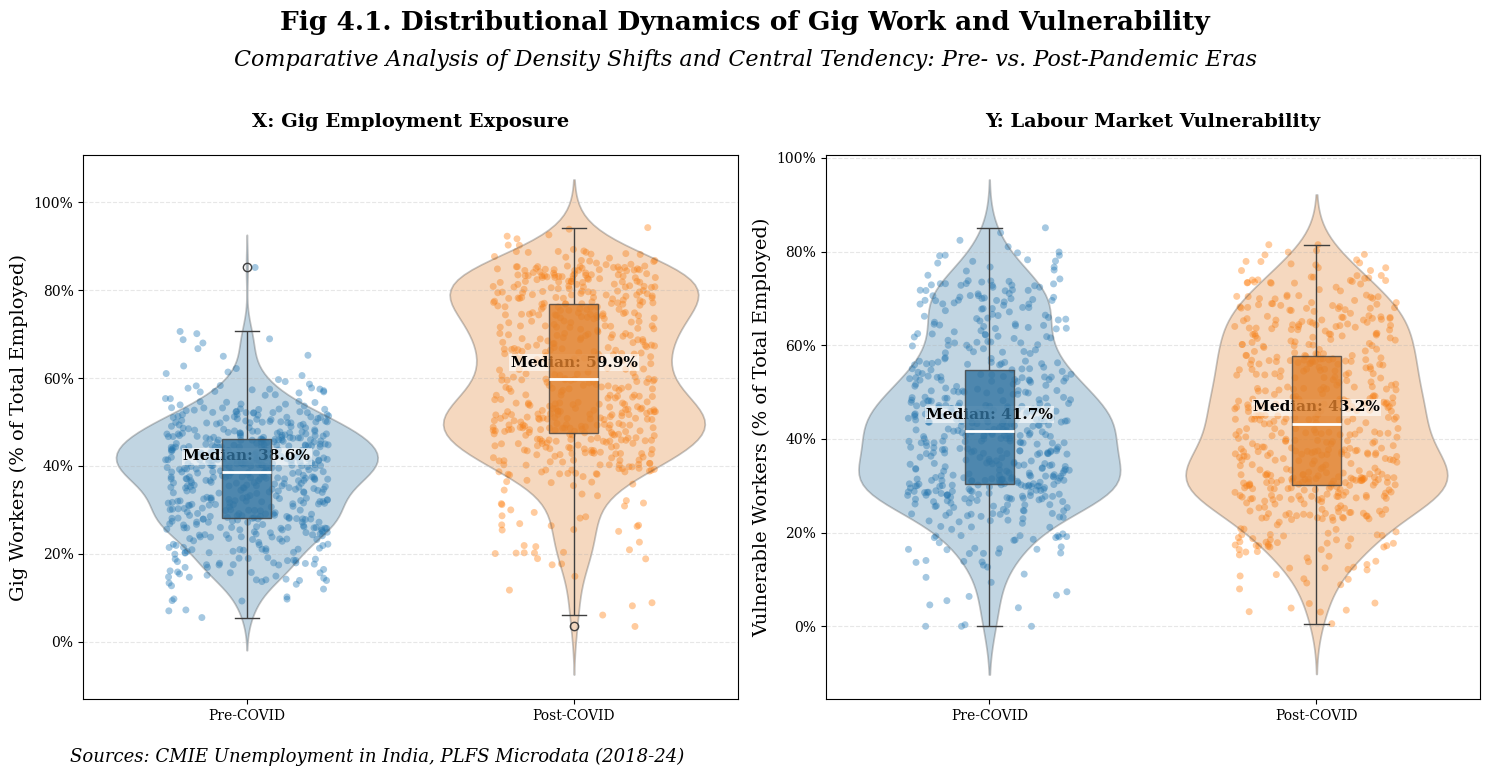

In [17]:
# Visualization 1 - Distributions of X and Y
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import pandas as pd # Ensure pandas is available
warnings.filterwarnings('ignore', category=FutureWarning)

# --- 1. Data Preparation (Fixes the KeyError) ---
def get_period(label):
    if label in ["2018_19", "2019_20"]: return "Pre-COVID"
    if label in ["2022_23", "2023_24"]: return "Post-COVID"
    return None

df['period'] = df['year_label'].apply(get_period)

# --- 2. Typography & Setup ---
plt.rcParams.update({"font.family": "serif"})
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
colors = {"Pre-COVID": "#1f77b4", "Post-COVID": "#ff7f0e"}

def plot_raincloud(ax, variable, title, ylabel):
    # Filter for the relevant variable and our new period column
    data = df[[variable, 'period']].dropna()
    
    # 1. Jittered Raw Points (the "Rain")
    sns.stripplot(x="period", y=variable, hue="period", data=data, palette=colors, 
                  ax=ax, size=5, jitter=0.25, alpha=0.4, zorder=1, legend=False)
    
    # 2. Boxplot (the "Inner Core")
    sns.boxplot(x="period", y=variable, hue="period", data=data, palette=colors, 
                ax=ax, width=0.15, zorder=10, showcaps=True, legend=False,
                boxprops={'alpha': 0.8}, medianprops={'color': 'white', 'linewidth': 2})
    
    # 3. Violin (the "Cloud")
    sns.violinplot(x="period", y=variable, hue="period", data=data, palette=colors, 
                   ax=ax, inner=None, alpha=0.3, bw_method=0.3, legend=False)
    
    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Annotate medians
    for i, p in enumerate(["Pre-COVID", "Post-COVID"]):
        subset = data[data['period'] == p][variable]
        if not subset.empty:
            med = subset.median()
            ax.text(i, med + 0.02, f"Median: {med:.1%}", ha='center', va='bottom', 
                    color='black', fontsize=11, fontweight='bold', 
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# --- 3. Execute Plotting ---
X_exposure = "gig_employment_share_principal" if "gig_employment_share_principal" in df.columns else "gig_occupation_code_share"

plot_raincloud(axes[0], X_exposure, 
               "X: Gig Employment Exposure", "Gig Workers (% of Total Employed)")
plot_raincloud(axes[1], "vulnerable_employment_share", 
               "Y: Labour Market Vulnerability", "Vulnerable Workers (% of Total Employed)")

fig.suptitle("Fig 4.1. Distributional Dynamics of Gig Work and Vulnerability", 
             fontsize=19, fontweight='bold', y=0.96)

fig.text(0.5, 0.89, 
         "Comparative Analysis of Density Shifts and Central Tendency: Pre- vs. Post-Pandemic Eras", 
         ha="center", fontsize=16, style='italic')

footnote_text = "Sources: CMIE Unemployment in India, PLFS Microdata (2018-24)"
fig.text(0.05, 0.02, footnote_text, ha="left", fontsize=13, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()


Motivation- Distributions test whether COVID coincided with broad-based shifts in X and Y, not only mean changes.

Economic question- Did gig exposure expand widely after COVID, and did vulnerability adjust commensurately?

Interpretation- Gig exposure shifts strongly rightward post-COVID: the median rises from about 39 percent to about 60 percent, with greater density at high exposure, indicating widespread expansion across labour markets. Vulnerable employment shifts only modestly with similar dispersion; the median rises from about 41.7 percent to about 43.2 percent. This asymmetry suggests that expanded platform exposure was not matched by improved security, consistent with protection deficits Z shaping persistent vulnerability.


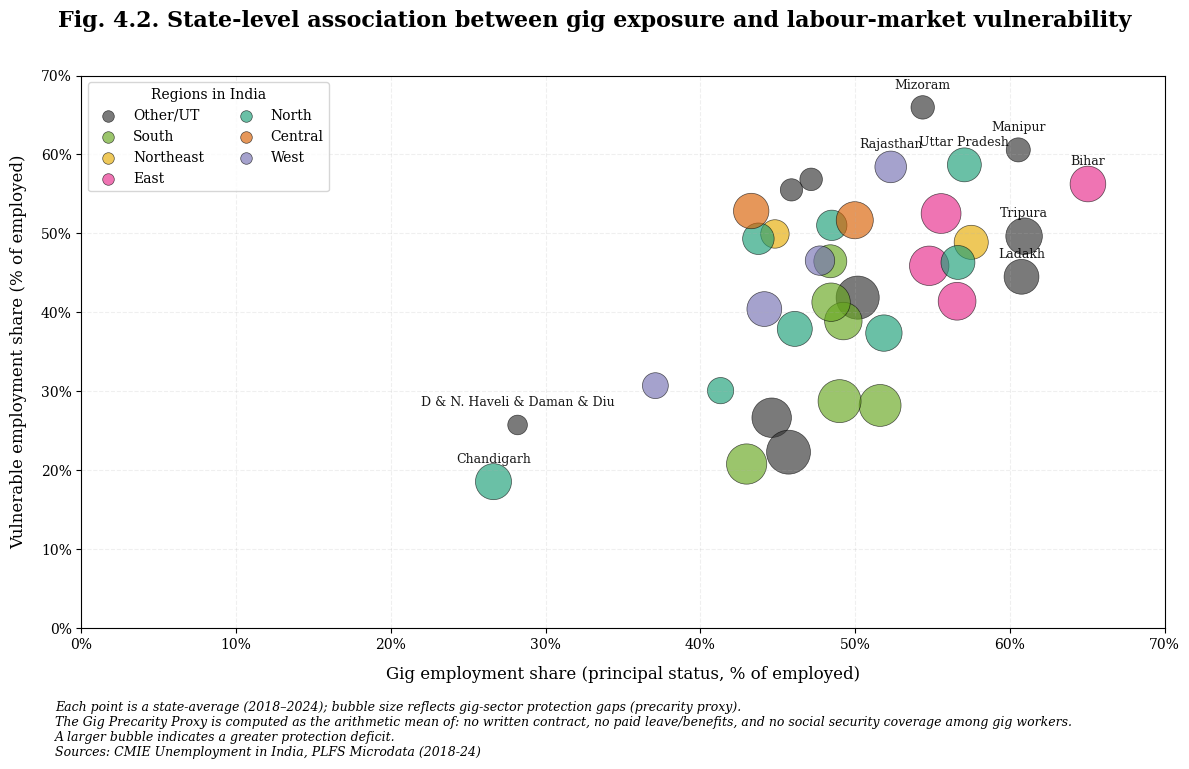

In [14]:
# Visualization 2 — Bubble Chart (Y vs X with Z as bubble size)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator

# ----------------------
# Constants (Fixes NameError)
# ----------------------
REGION_MAP = {
    "Jammu & Kashmir": "North", "Himachal Pradesh": "North", "Punjab": "North",
    "Chandigarh": "North", "Haryana": "North", "Delhi": "North",
    "Uttarakhand": "North", "Uttar Pradesh": "North",
    "Madhya Pradesh": "Central", "Chhattisgarh": "Central",
    "Rajasthan": "West", "Gujarat": "West", "Maharashtra": "West", "Goa": "West",
    "Bihar": "East", "Jharkhand": "East", "West Bengal": "East", "Odisha": "East",
    "Andhra Pradesh": "South", "Telangana": "South", "Karnataka": "South",
    "Kerala": "South", "Tamilnadu": "South", "Puduchery": "South",
    "Assam": "Northeast", "Sikkim": "Northeast" # Add others as needed
}

REGION_COLORS = {
    "North": "#1b9e77", "Central": "#d95f02", "West": "#7570b3", 
    "East": "#e7298a", "South": "#66a61e", "Northeast": "#e6ab02", "Other/UT": "#333333"
}

# ----------------------
# Typography Fallback
# ----------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

# ----------------------
# Data Preparation
# ----------------------
proxy_cols = ["gig_no_paid_leave_share", "gig_no_written_contract_share", "gig_no_socsec_share"]
for col in proxy_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df["precarity_proxy"] = df[proxy_cols].mean(axis=1)

X_exposure = "gig_employment_share_principal" if "gig_employment_share_principal" in df.columns else "gig_occupation_code_share"
needed = ["state", "vulnerable_employment_share", "precarity_proxy", X_exposure]
d = df.dropna(subset=needed).copy()
d["region"] = d["state"].map(REGION_MAP).fillna("Other/UT")

state_avg = (
    d.groupby(["state", "region"], observed=False)[["vulnerable_employment_share", "precarity_proxy", X_exposure]]
     .mean().reset_index()
)

# Bubble size scaling
z = state_avg["precarity_proxy"].astype(float)
z_scaled = (z - z.min()) / (z.max() - z.min() + 1e-9)
state_avg['bubble_size'] = (z_scaled * 800) + 200

# ----------------------
# Plotting
# ----------------------
fig, ax = plt.subplots(figsize=(12, 8))

for reg in state_avg["region"].unique():
    sub = state_avg[state_avg["region"] == reg].copy()
    
    ax.scatter(
        sub[X_exposure],
        sub["vulnerable_employment_share"],
        s=sub['bubble_size'], # Fixed reference
        alpha=0.65,
        edgecolor="black",
        linewidth=0.5,
        color=REGION_COLORS.get(reg, "#333333"),
        label=reg
    )

# ----------------------
# Axes Formatting
# ----------------------
ax.set_xlabel("Gig employment share (principal status, % of employed)", labelpad=10)
ax.set_ylabel("Vulnerable employment share (% of employed)", labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_locator(MultipleLocator(0.10))
ax.yaxis.set_major_locator(MultipleLocator(0.10))
ax.set_xlim(left=0, right=0.7)
ax.set_ylim(bottom=0, top=0.7)
ax.grid(alpha=0.2, linestyle="--")

# ----------------------
# Titles, Legend & Labeling
# ----------------------
fig.suptitle("Fig. 4.2. State-level association between gig exposure and labour-market vulnerability", 
             fontsize=16, fontweight="bold", y=0.94)

lgnd = ax.legend(title="Regions in India", frameon=True, ncol=2, loc="upper left", fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([70.0])

x_hi, x_lo = state_avg[X_exposure].quantile(0.9), state_avg[X_exposure].quantile(0.1)
y_hi, y_lo = state_avg["vulnerable_employment_share"].quantile(0.9), state_avg["vulnerable_employment_share"].quantile(0.1)

for _, r in state_avg.iterrows():
    if r[X_exposure] > x_hi or r["vulnerable_employment_share"] > y_hi or \
       (r[X_exposure] < x_lo and r["vulnerable_employment_share"] < y_lo):
        
        ax.text(r[X_exposure], r["vulnerable_employment_share"] + 0.02, 
                r["state"], fontsize=9, ha='center', va='bottom', alpha=0.9)

# ----------------------
# Footnote
# ----------------------
footnote_text = (
    "Each point is a state-average (2018–2024); bubble size reflects gig-sector protection gaps (precarity proxy). \n"
    "The Gig Precarity Proxy is computed as the arithmetic mean of: no written contract, no paid leave/benefits, and no social security coverage among gig workers. \n"
    "A larger bubble indicates a greater protection deficit.\n"
    "Sources: CMIE Unemployment in India, PLFS Microdata (2018-24)"
)
fig.text(0.05, 0.01, footnote_text, ha="left", fontsize=9, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

Motivation- A state-level X–Y scatter tests whether more platform-exposed labour markets are also more vulnerable; bubble size summarizes Z.

Economic question- Is higher gig exposure associated with higher vulnerability, and how does gig-sector precarity vary across states?

Interpretation- The association is generally positive: higher gig exposure tends to coincide with higher vulnerable employment. However, bubble size is not monotone in X or Y. Several high-exposure/high-vulnerability states have comparatively smaller bubbles, while some mid-range states have larger bubbles, indicating more severe protection deficits. This suggests that Z varies independently of gig intensity, consistent with heterogeneity in enforcement and the quality of gig jobs across states.


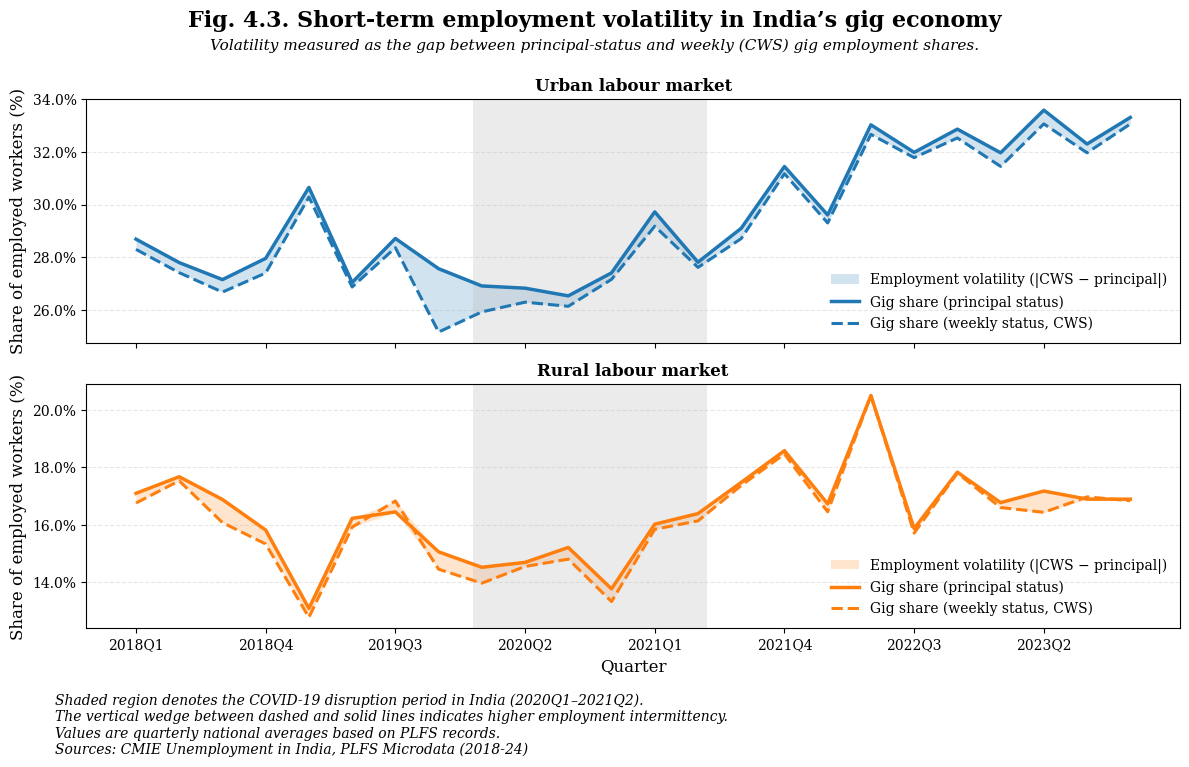

In [15]:
# Visualization 3 - Consistency Update

# ----------------------
# Typography: Serif Fallback 
# ----------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

# ======================
# Build quarterly time index (Data logic remains identical)
# ======================
QUARTER_MAP = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4, 1: 1, 2: 2, 3: 3, 4: 4}

df["year_start"] = pd.to_numeric(df["year_label"].astype(str).str[:4], errors="coerce")
df["q_num"] = df["quarter"].map(QUARTER_MAP)
df = df.dropna(subset=["year_start", "q_num"]).copy()
df["q_num"] = df["q_num"].astype(int)

df["t_index"] = df["year_start"] * 4 + (df["q_num"] - 1)
df["t_label"] = df["year_start"].astype(str) + "Q" + df["q_num"].astype(str)

sector_map = {"rural": "Rural", "urban": "Urban", "Rural": "Rural", "Urban": "Urban"}
df["region_sector"] = df["region"].map(sector_map) # Renamed to avoid confusion with REGION_MAP

needed = ["t_index", "t_label", "region_sector", "gig_occupation_code_share", "gig_occupation_code_cws_share"]
d = df.dropna(subset=needed).copy()

ts = (
    d.groupby(["region_sector", "t_index", "t_label"], observed=False)
     .agg(
          principal=("gig_occupation_code_share", "mean"),
          cws=("gig_occupation_code_cws_share", "mean")
     )
     .reset_index()
     .sort_values(["region_sector", "t_index"])
)

# ======================
# Plot settings
# ======================
COLORS = {"Urban": "#1f77b4", "Rural": "#ff7f0e"}
COVID_SHADE = "#bdbdbd"

def add_covid_shading(ax, sub, start="2020Q1", end="2021Q2"):
    s = sub.loc[sub["t_label"] == start, "t_index"]
    e = sub.loc[sub["t_label"] == end, "t_index"]
    if len(s) and len(e):
        ax.axvspan(s.iloc[0] - 0.2, e.iloc[0] + 0.2, color=COVID_SHADE, alpha=0.30, lw=0)

# ======================
# Plotting
# ======================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for region, ax in zip(["Urban", "Rural"], axes):
    sub = ts[ts["region_sector"] == region].copy()
    if sub.empty: continue

    lower = np.minimum(sub["principal"], sub["cws"])
    upper = np.maximum(sub["principal"], sub["cws"])

    ax.fill_between(sub["t_index"], lower, upper, color=COLORS[region], 
                    alpha=0.20, linewidth=0, label="Employment volatility (|CWS − principal|)")

    ax.plot(sub["t_index"], sub["principal"], color=COLORS[region], lw=2.5, label="Gig share (principal status)")
    ax.plot(sub["t_index"], sub["cws"], color=COLORS[region], lw=2.2, linestyle="--", label="Gig share (weekly status, CWS)")

    add_covid_shading(ax, sub)

    ax.set_title(f"{region} labour market", fontsize=12, fontweight="bold")
    ax.set_ylabel("Share of employed workers (%)", fontsize=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.legend(frameon=False, loc="lower right", fontsize=10)

# X-axis
ticks = sorted(ts["t_index"].unique())
labels = ts.drop_duplicates("t_index").sort_values("t_index")["t_label"]
step = max(1, len(ticks) // 8)
axes[-1].set_xticks(ticks[::step])
axes[-1].set_xticklabels(labels.iloc[::step])
axes[-1].set_xlabel("Quarter", fontsize=12)

# ======================
# Titles & Footnote 
# ======================
fig.suptitle("Fig. 4.3. Short-term employment volatility in India’s gig economy", 
             fontsize=16, fontweight="bold", y=0.93)

# Main sub-description (Matches your "Bubble size reflects..." style)
fig.text(0.5, 0.88, "Volatility measured as the gap between principal-status and weekly (CWS) gig employment shares.", 
         ha="center", fontsize=11, style='italic')

footnote_text = (
    "Shaded region denotes the COVID-19 disruption period in India (2020Q1–2021Q2).\n"
    "The vertical wedge between dashed and solid lines indicates higher employment intermittency.\n"
    "Values are quarterly national averages based on PLFS records.\n"
    "Sources: CMIE Unemployment in India, PLFS Microdata (2018-24)"
)
fig.text(0.05, 0.0025, footnote_text, ha="left", fontsize=10, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.91])
plt.show()

Motivation- The volatility wedge captures short-horizon intermittency central to platform work and earnings risk.

Economic question- Did COVID generate a volatility episode in gig work, and do dynamics differ by urban versus rural labour markets?

Interpretation- The wedge is most pronounced around the disruption window and narrows post-COVID, implying reduced intermittency relative to the shock period rather than sustained intensification. Urban markets sustain higher gig participation with moderation in volatility as conditions stabilize; rural markets show lower gig shares but larger quarter-to-quarter movement, consistent with thinner labour markets and weaker smoothing capacity. COVID appears to have triggered a temporary volatility spike while elevated gig participation persists.


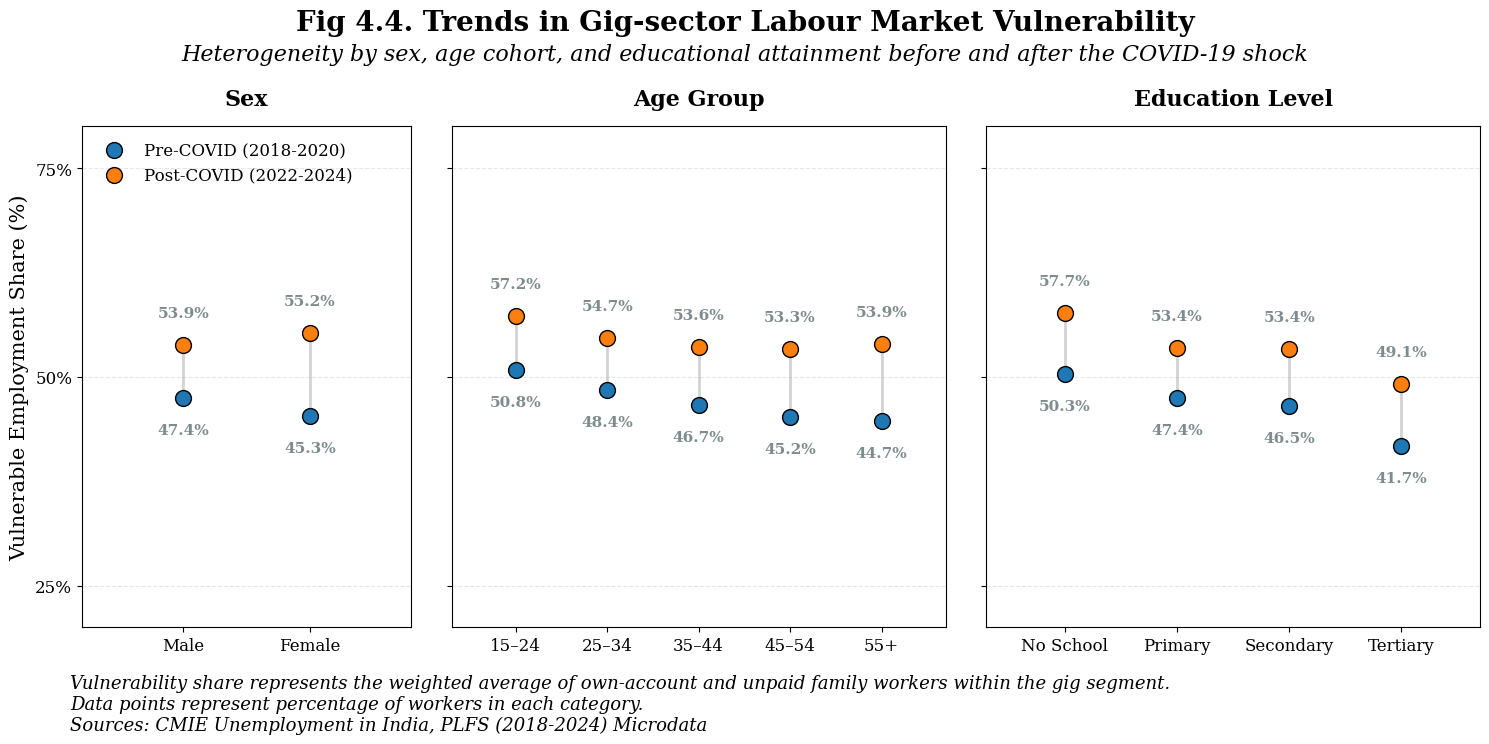

In [16]:
# Visualization 4 - Standardized Demographic Analysis
# ----------------------
# Typography: Serif Fallback
# ----------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 13, 
    "axes.labelsize": 13,
})

# 1. Define Categories and Metrics
v_col = "vulnerable_employment_share"
weight_col = "gig_employed_weighted"

groups = {
    "Sex": {"Male": "gig_male_share_within_gig", "Female": "gig_female_share_within_gig"},
    "Age Group": {
        "15–24": "gig_age_15_24_share_within_gig", "25–34": "gig_age_25_34_share_within_gig",
        "35–44": "gig_age_35_44_share_within_gig", "45–54": "gig_age_45_54_share_within_gig",
        "55+": "gig_age_55p_share_within_gig"
    },
    "Education Level": {
        "No School": "gig_edu_no_schooling_share_within_gig", "Primary": "gig_edu_primary_share_within_gig",
        "Secondary": "gig_edu_secondary_share_within_gig", "Tertiary": "gig_edu_tertiary_share_within_gig"
    }
}

# 2. Period Mapping & Cleaning
def get_period(label):
    if label in ["2018_19", "2019_20"]: return "Pre-COVID"
    if label in ["2022_23", "2023_24"]: return "Post-COVID"
    return None

df['period'] = df['year_label'].apply(get_period)
for section in groups.values():
    for col in section.values():
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 7.5), sharey=True, gridspec_kw={'width_ratios': [1.5, 2.25, 2.25]})

# Updated color scheme: Blue for Pre-COVID, Orange for Post-COVID
color_pre, color_post = "#1f77b4", "#ff7f0e" 
line_color = "#d3d3d3" # Lighter grey for the connecting line to let markers pop

for i, section in enumerate(groups.keys()):
    ax = axes[i]
    categories = list(groups[section].keys())
    
    # ADJUSTED: Added consistent padding to all plots to move points away from the Y-axis
    if section == "Sex": 
        ax.set_xlim(-0.8, 1.8) # Widened from -0.6/1.6
    elif section == "Age Group":
        ax.set_xlim(-0.7, len(categories) - 0.3) # Shifts the age points right
    else: # Education Level
        ax.set_xlim(-0.7, len(categories) - 0.3) # Shifts the education points right

    for j, cat in enumerate(categories):
        col_name = groups[section][cat]
        vals = []
        for period in ["Pre-COVID", "Post-COVID"]:
            sub = df[df['period'] == period].dropna(subset=[v_col, weight_col, col_name])
            weight = sub[weight_col] * sub[col_name]
            vals.append((sub[v_col] * weight).sum() / weight.sum())
        
        pre_val, post_val = vals[0], vals[1]
        
        ax.plot([j, j], [pre_val, post_val], color=line_color, lw=2, zorder=1)
        ax.scatter(j, pre_val, color=color_pre, s=130, edgecolors='black', label='Pre-COVID (2018-2020)' if i==0 and j==0 else "", zorder=3)
        ax.scatter(j, post_val, color=color_post, s=130, edgecolors='black', label='Post-COVID (2022-2024)' if i==0 and j==0 else "", zorder=3)
        
        ax.text(j, pre_val - 0.03, f"{pre_val:.1%}", ha='center', va='top', fontsize=11, color='#7f8c8d', fontweight='bold', clip_on=False)
        ax.text(j, post_val + 0.03, f"{post_val:.1%}", ha='center', va='bottom', fontsize=11, color='#7f8c8d', fontweight='bold', clip_on=False)

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=0, fontsize=12)
    ax.set_title(section, fontsize=16, fontweight='bold', pad=15)
    
    ax.set_ylim(0.2, 0.8) 
    ax.yaxis.set_major_locator(mtick.MultipleLocator(0.25))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='y', labelsize=12)

    if i == 0:
        ax.set_ylabel("Vulnerable Employment Share (%)", fontsize=15)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.legend(frameon=False, loc='upper left', fontsize=12)

# ======================
# Titles & Footnotes
# ======================
fig.suptitle("Fig 4.4. Trends in Gig-sector Labour Market Vulnerability", 
             fontsize=20, fontweight='bold', y=0.96) # Main heading size 15
fig.text(
    0.5, 0.915,
    "Heterogeneity by sex, age cohort, and educational attainment before and after the COVID-19 shock",
    ha="center", va="top", fontsize=16, style='italic'
)

footnote_text = (
    "Vulnerability share represents the weighted average of own-account and unpaid family workers within the gig segment.\n"
    "Data points represent percentage of workers in each category.\n"
    "Sources: CMIE Unemployment in India, PLFS (2018-2024) Microdata"
)
fig.text(0.05, 0.0025, footnote_text, ha="left", fontsize=13, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

Motivation- Stratifying by sex, age, and education tests heterogeneity in gig vulnerability along margins linked to sorting, bargaining power, and access to protected work.

Economic question- How did COVID shift vulnerability within gig work across demographic groups, and what does this imply about Z?

Interpretation- Vulnerable employment increases post-COVID for all groups, indicating broad deterioration in gig job quality. By education, tertiary-educated gig workers still experience an increase from about 41.7 percent to about 49.1 percent, reinforcing that precarity reflects employment form and protections, not only skill. Age gradients remain: younger cohorts are most vulnerable, consistent with weaker attachment and outside options. Gender imbalance persists and vulnerability rises for both men and women, consistent with protection gaps affecting diverse workers within gig employment

5.Conclusion

Using merged CMIE and PLFS data, this project documents descriptive co-movement between platform-adjacent exposure, labour-market vulnerability, and protection deficits across states and rural–urban labour markets. Evidence shows a broad post-COVID rise in gig exposure, while vulnerable employment remains persistently high and increases across demographic groups, indicating that greater reliance on gig work did not translate into improved job quality.

The patterns are consistent with weak employment protection as a plausible channel but highlight heterogeneity: the X–Y association is generally positive, yet Z varies widely and does not scale monotonically with gig intensity. Volatility spikes around the disruption window and partially normalizes post-COVID, suggesting intermittency was amplified by the shock even as elevated gig participation persists.

Key limitations are that the analysis is descriptive, does not explicitly model sector/platform composition, and may omit institutional covariates that help explain cross-state differences in Z. These constraints motivate future work incorporating sectoral detail and institutional measures to better assess how platform expansion translates into labour-market vulnerability through protection gaps.


References:
1.  Rani, U., & Dhir, R. K. (2020). Platform Work and the COVID-19 Pandemic. The Indian Journal of Labour Economics, 63, 1–9. https://doi.org/10.1007/s41027-020-00273-y 
2. Parwez, S. (2022). COVID-19 pandemic and work precarity at digital food platforms: A delivery worker’s perspective. Social Sciences & Humanities Open, 5(1), 100259. https://doi.org/10.1016/j.ssaho.2022.100259
3. Sharma, A. K., & Sharma, R. (2025). The Gig Economy and the Evolving Nature of Work in India: Employment, Policy, and Platform Realities in the Age of Convenience. Journal of Digital Economy. https://doi.org/10.1016/j.jdec.2025.07.005
4. NITI Aayog. (2022). India’s Booming Gig and Platform Economy: Perspectives and Recommendations on the Future of Work. Government of India. https://www.niti.gov.in/sites/default/files/2022-06/25th_June_Final_Report_27062022.pdf
5. Bussolo, M., Kotia, A., & Sharma, S. (2021). Workers at Risk: Panel Data Evidence on the COVID-19 Labor Market Crisis in India. World Bank Policy Research Working Paper. https://doi.org/10.1596/1813-9450-9584